## Exercício — Simulação da distribuição normal

Considere a densidade da normal padrão,

$$
f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2},
$$

e, para $x>0$, utilize como distribuição proposta uma exponencial com taxa $1$,

$$
g(x)=e^{-x}, \qquad x\geq 0.
$$

1. Para aplicar o método de rejeição-aceitação, determine a constante

$$
c=\sup_{x>0}\frac{f(x)}{g(x)}.
$$

Para isso, encontre o ponto de máximo da razão $f(x)/g(x)$ e obtenha a expressão da probabilidade de aceitação

$$
\frac{f(x)}{c\,g(x)}.
$$

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
from utils.distribuicoes import exp

In [31]:
c = 2/np.sqrt(2*np.pi)*np.exp(1/2)
c

np.float64(1.315489246958914)

2. A partir do resultado anterior, implemente em Python um algoritmo de rejeição-aceitação para gerar uma amostra de tamanho $n$ da distribuição de $|N(0,1)|$.

In [33]:
def densidade_normal(x, mi=0, sigma2=1):
    return np.exp(-((x - mi)**2) / (2 * sigma2)) / np.sqrt(2 * np.pi * sigma2)


In [34]:
def densidade_exponencial(x, lamb = 1):
    return lamb * np.exp(-lamb*x)

In [35]:
amostra_normal = []
K = 10_000
sucessos = 0

while sucessos < K:
    y = exp(M = 1)[0]
    u = np.random.uniform()
    if u < densidade_normal(y)/(densidade_exponencial(y)*c):
        amostra_normal.append(y)
        sucessos += 1

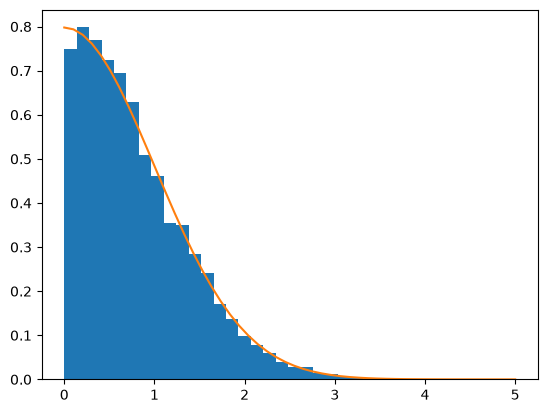

In [39]:
plt.hist(amostra_normal, density= True, bins = 30)
x = np.linspace(0,5)
fx = densidade_normal(x) * 2
plt.plot(x,fx)

3. Utilize sinais aleatórios independentes, com probabilidades iguais de serem positivos ou negativos, para transformar essa amostra em uma amostra de

$$
N(0,1).
$$

Gere também uma amostra de mesmo tamanho utilizando `numpy.random.normal` e compare as duas distribuições por meio de histogramas.

In [40]:
amostra_normal = []
K = 10_000
sucessos = 0

while sucessos < K:
    y = exp(M = 1)[0]
    u = np.random.uniform()
    if u < densidade_normal(y)/(densidade_exponencial(y)*c):
        m = np.random.uniform()
        amostra_normal.append(y* -1**(m < .5))
        sucessos += 1

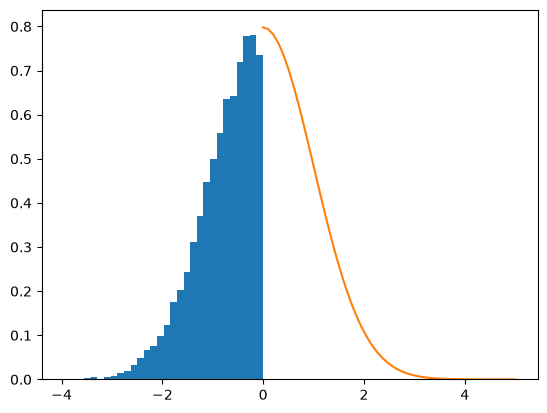

In [41]:
plt.hist(amostra_normal, density= True, bins = 30)
x = np.linspace(0,5)
fx = densidade_normal(x) * 2
plt.plot(x,fx)

4. Suponha agora que você saiba gerar $Z\sim N(0,1)$. Como você pode utilizar $Z$ para gerar

$$
X\sim N(\mu,\sigma^2)?
$$

Implemente essa transformação para gerar uma amostra de tamanho $n$ de $N(\mu,\sigma^2)$.

5. Gere também uma amostra de $N(\mu,\sigma^2)$ utilizando `numpy.random.normal` e compare os histogramas das duas amostras.

6. Durante a simulação, registre o número total de propostas geradas e calcule a taxa empírica de aceitação,

$$
\widehat{p}_{\text{aceitação}}
=
\frac{\text{número de valores aceitos}}
{\text{número total de propostas}}.
$$

Compare esse valor com a taxa teórica de aceitação do método,

$$
p_{\text{aceitação}}=\frac{1}{c},
$$

onde $c$ é a constante obtida anteriormente. Os valores observado e esperado são compatíveis?

In [32]:
densidade_normal(5)

np.float64(214102.1780027406)